In [44]:
# pyrefly: ignore [missing-import]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS

In [5]:
# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

# Raed in the database
salary_df = pd.read_csv(path+"/Salary_dataset.csv")

In [6]:
# Database describtions
print(salary_df.head())
salary_df.drop(salary_df.columns[[0]], axis = 1, inplace=True)
print(salary_df.head())

print("\nData Description")
print(salary_df.describe())

print("\nMissing Values")
print(salary_df.isnull().sum())

print("\nData Info")
salary_df.info()

print("\nData Shape")
print(salary_df.shape)

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0

Data Description
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.413333   76004.000000
std           2.837888   27414.429785
min           1.200000   37732.000000
25%           3.300000   56721.750000
50%           4.800000   65238.000000
75%           7.800000  100545.750000
max          10.600000  122392.000000

Missing Values
YearsExperience    0
Salary             0
dtype: int64

Data Info
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------  

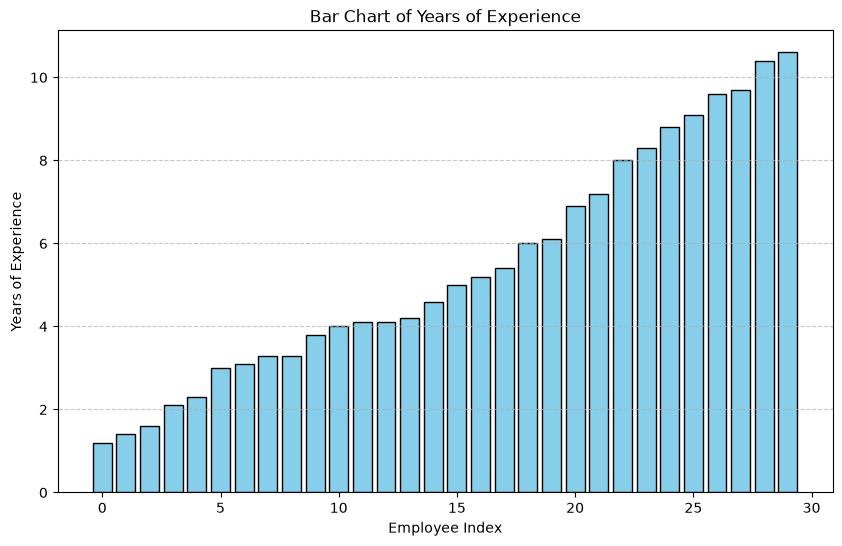

In [17]:
# Bar chart of Years of Experience
plt.figure(figsize=(10, 6))
plt.bar(salary_df.index, salary_df['YearsExperience'], color='skyblue', edgecolor='black')
plt.xlabel('Employee Index')
plt.ylabel('Years of Experience')
plt.title('Bar Chart of Years of Experience')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

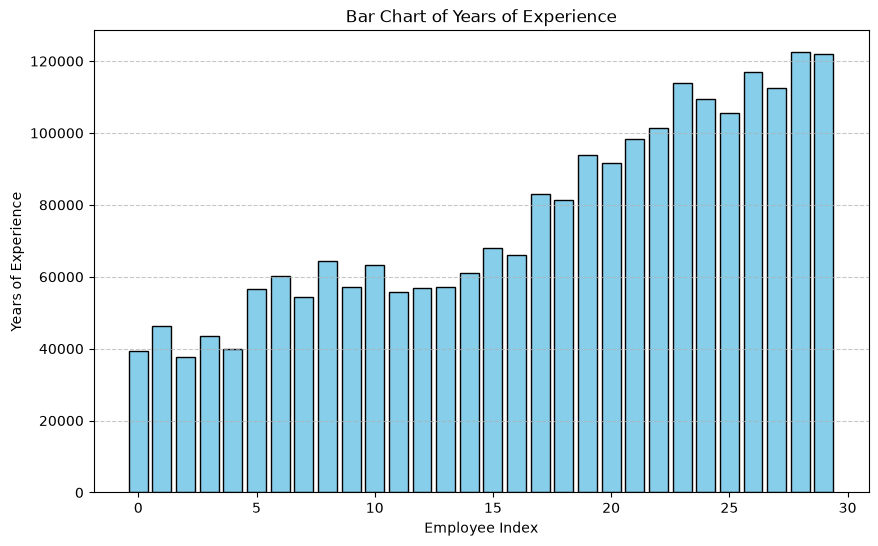

In [18]:
# Bar chart of Years of Experience
plt.figure(figsize=(10, 6))
plt.bar(salary_df.index, salary_df['Salary'], color='skyblue', edgecolor='black')
plt.xlabel('Employee Index')
plt.ylabel('Years of Experience')
plt.title('Bar Chart of Years of Experience')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

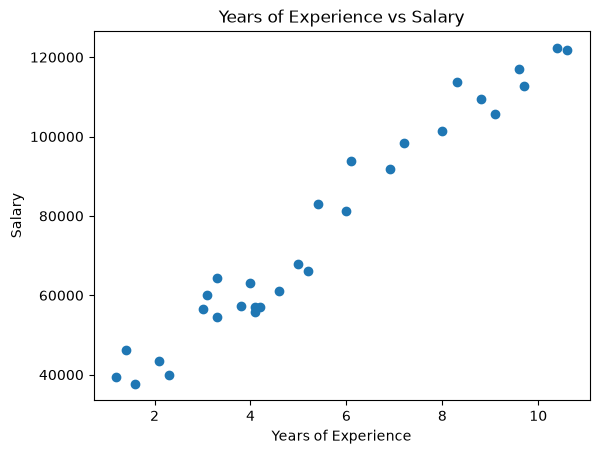

In [14]:
# Visualisation
plt.scatter(salary_df['YearsExperience'],salary_df['Salary'])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.show()

Correlation analysis
                 YearsExperience    Salary
YearsExperience         1.000000  0.978242
Salary                  0.978242  1.000000


<Axes: >

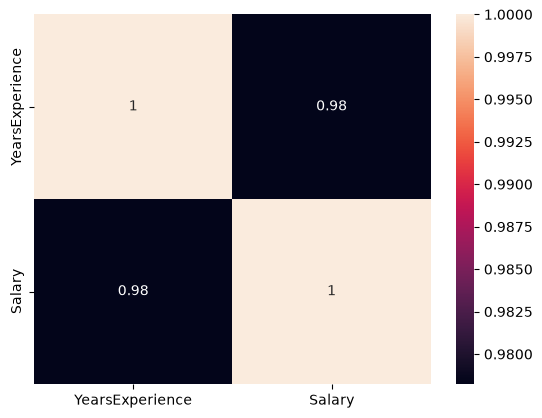

In [13]:
#Correlation analysis
salary_corellation = salary_df.corr()
print("Correlation analysis")
print(salary_corellation)
sns.heatmap(salary_corellation, annot = True)

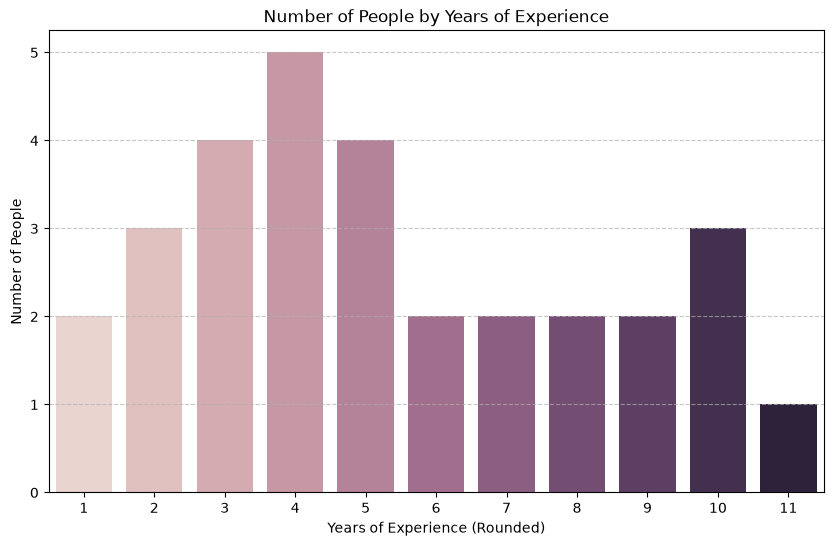

In [20]:
# Bar chart of how many people have each level of experience (rounded to nearest integer)
experience_counts = salary_df['YearsExperience'].round().value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=experience_counts.index.astype(int), y=experience_counts.values, hue=experience_counts.index.astype(int), legend=False)
plt.xlabel('Years of Experience (Rounded)')
plt.ylabel('Number of People')
plt.title('Number of People by Years of Experience')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
salary_df['Salary'].round(-3).value_counts().sort_index()

Salary
38000.0     1
39000.0     1
40000.0     1
44000.0     1
46000.0     1
54000.0     1
56000.0     1
57000.0     4
60000.0     1
61000.0     1
63000.0     1
64000.0     1
66000.0     1
68000.0     1
81000.0     1
83000.0     1
92000.0     1
94000.0     1
98000.0     1
101000.0    1
106000.0    1
109000.0    1
113000.0    1
114000.0    1
117000.0    1
122000.0    2
Name: count, dtype: int64

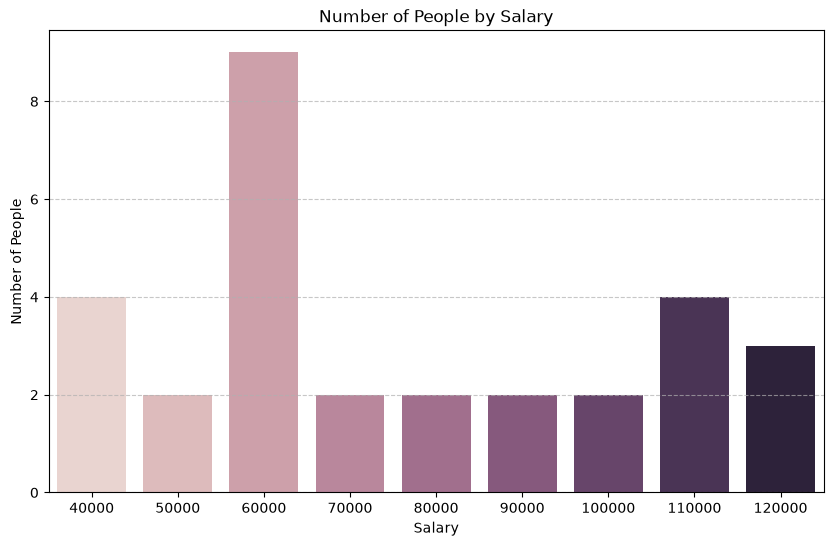

In [35]:
# Number of people by salary ranges
experience_counts = salary_df['Salary'].round(-4).value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=experience_counts.index.astype(int), y=experience_counts.values, hue=experience_counts.index.astype(int), legend=False)
plt.xlabel('Salary')
plt.ylabel('Number of People')
plt.title('Number of People by Salary')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [40]:
# Running linear regression
y_variable = pd.DataFrame(salary_df["Salary"])
x_variables = pd.DataFrame(salary_df["YearsExperience"])
model = LinearRegression().fit(x_variables, y_variable)

print("R-squared: ", model.score(x_variables, y_variable))

R-squared:  0.9569566641435086
